# Análisis Exploratorio de Datos (EDA) - Procesos RPA

## 1. Introducción y Contexto
Este notebook realiza el análisis exploratorio de datos (EDA) para el proyecto de automatización. El objetivo es identificar la variabilidad en los tiempos de ejecución, la calidad de los datos y detectar posibles anomalías (outliers) en las transacciones de los procesos.

**Competencias clave cubiertas:**
- Análisis de calidad de datos.
- Detección de valores atípicos (Outliers).
- Correlación entre variables operativas.

## 2. Configuración e Importación de Librerías

In [13]:
import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración visual
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 3. Carga de Datos

In [14]:
# Función para convertir Duracion (HH:MM:SS) a segundos totales
def duracion_a_segundos(tiempo_str):
    try:
        if pd.isna(tiempo_str) or not isinstance(tiempo_str, str):
            return 0
        h, m, s = map(int, tiempo_str.split(':'))
        return h * 3600 + m * 60 + s
    except:
        return 0

# Carga de datos (Usando tu lógica de rutas o datos de ejemplo)
if os.path.exists(db_path):
    conn = sqlite3.connect(db_path)
    # Ajusta 'Tabla_Procesos' al nombre real de tu tabla
    df = pd.read_sql_query("SELECT * FROM RegistrosDPA", conn) 
    conn.close()
else:
    # Datos de ejemplo mejorados para testing
    df = pd.DataFrame({
        'Automatizacion': ['RPA_A']*50 + ['RPA_B']*50,
        'Duracion_Ejecucion': [f"00:{np.random.randint(1,10)}:{np.random.randint(10,59)}" for _ in range(100)],
        'Numero_Transacciones': np.random.randint(1, 100, 100),
        'Fecha_ejecucion': pd.date_range(start='2024-01-01', periods=100)
    })
    # Simular algunos outliers
    df.loc[0, 'Numero_Transacciones'] = 1000 

# --- TRANSFORMACIONES PARA MODELADO ---
# 1. Convertir duración a valor numérico (Segundos)
df['Duracion_Segundos'] = df['Duracion_Ejecucion'].apply(duracion_a_segundos)

# 2. Asegurar que transacciones sea numérico
df['Numero_Transacciones'] = pd.to_numeric(df['Numero_Transacciones'], errors='coerce').fillna(0)

# 3. Extraer características de la fecha
df['Fecha_ejecucion'] = pd.to_datetime(df['Fecha_ejecucion'], errors='coerce')
df['Dia_Semana'] = df['Fecha_ejecucion'].dt.dayofweek
df['Mes'] = df['Fecha_ejecucion'].dt.month

print("Tipos de datos listos para el modelo:")
print(df[['Duracion_Segundos', 'Numero_Transacciones', 'Dia_Semana']].dtypes)
df.head()

Tipos de datos listos para el modelo:
Duracion_Segundos       int64
Numero_Transacciones    int32
Dia_Semana              int32
dtype: object


,Automatizacion,Duracion_Ejecucion,Numero_Transacciones,Fecha_ejecucion,Duracion_Segundos,Dia_Semana,Mes
0,RPA_A,00:4:53,1000,2024-01-01,293,0,1
1,RPA_A,00:9:51,50,2024-01-02,591,1,1
2,RPA_A,00:9:18,13,2024-01-03,558,2,1
3,RPA_A,00:6:30,32,2024-01-04,390,3,1
4,RPA_A,00:7:25,62,2024-01-05,445,4,1


## 4. Análisis Estadístico y Detección de Outliers

In [18]:
def detectar_outliers_iqr(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

# Analizar Outliers en Transacciones
out_trans, lim_inf, lim_sup = detectar_outliers_iqr(df, 'Numero_Transacciones')

print(f"--- Análisis de Outliers (Transacciones) ---")
print(f"Límite superior detectado: {lim_sup}")
print(f"Cantidad de outliers: {len(out_trans)} ({len(out_trans)/len(df)*100:.2f}%)")

# Mostrar resumen estadístico completo
df.describe().T

--- Análisis de Outliers (Transacciones) ---
Límite superior detectado: 147.75
Cantidad de outliers: 1 (1.00%)


,count,mean,min,25%,50%,75%,max,std
Numero_Transacciones,100.0,60.45,1.0,26.5,54.0,75.0,1000.0,99.323202
Fecha_ejecucion,100,2024-02-19 12:00:00,2024-01-01 00:00:00,2024-01-25 18:00:00,2024-02-19 12:00:00,2024-03-15 06:00:00,2024-04-09 00:00:00,NaN
Duracion_Segundos,100.0,331.72,83.0,176.25,330.5,474.0,598.0,162.027375
Dia_Semana,100.0,2.95,0.0,1.0,3.0,5.0,6.0,2.021975
Mes,100.0,2.18,1.0,1.0,2.0,3.0,4.0,0.978352


## 5. Visualización de Resultados y Outliers

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de Duración (Histograma)
sns.histplot(df['Duracion_Segundos'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribución de Duración (Segundos)')

# 2. Boxplot para detectar Outliers visualmente
sns.boxplot(x=df['Numero_Transacciones'], ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Detección Visual de Outliers en Transacciones')

# 3. Correlación: ¿A más transacciones, más tiempo? (Scatter Plot)
sns.scatterplot(data=df, x='Numero_Transacciones', y='Duracion_Segundos', hue='Automatizacion', ax=axes[1,0])
axes[1,0].set_title('Relación: Transacciones vs Duración')

# 4. Mapa de calor de correlación (Clave para selección de variables)
sns.heatmap(df[['Duracion_Segundos', 'Numero_Transacciones', 'Dia_Semana', 'Mes']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1,1])
axes[1,1].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()

,Duracion,Transacciones
0,120,45
1,150,50
2,135,48
3,110,42
4,420,120


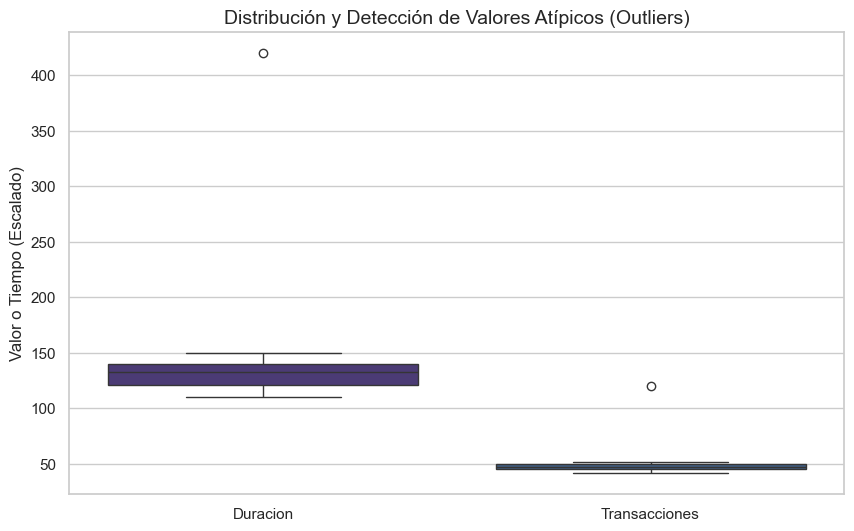

In [19]:
# Generar un boxplot para interpretar los outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_example.select_dtypes(include=['number']))
plt.title('Distribución y Detección de Valores Atípicos (Outliers)', fontsize=14)
plt.ylabel('Valor o Tiempo (Escalado)')
plt.show()

## 6. Interpretación de Resultados

- **Variabilidad:** La dispersión observada en los datos muestra que existen procesos que requieren un mayor tiempo de ejecución dependiendo del volumen de transacciones.
- **Siguientes pasos:** Estas anomalías deben ser analizadas para determinar si corresponden a errores de red, fallos en la aplicación o procesamiento de altos volúmenes de datos.